In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [33]:
# drawing a simple triangle
# plt.figure(figsize=(8,8))
# plt.plot([0,4],[0,5], marker='o',color='b')
# plt.plot([0,6],[0,2], marker='o',color='b')
# plt.plot([4,6],[5,2], marker='o',color='b')
# plt.xlim(right=8)
# plt.ylim(top=8)

In [34]:
from sklearn.datasets import make_regression
X, y=make_regression(n_samples=1000, n_features=2, n_targets=1, noise=3)


In [35]:
X

array([[-0.41658555, -1.04328436],
       [-0.48683539,  1.9263487 ],
       [ 0.7751576 ,  1.22881806],
       ...,
       [-1.33938808,  1.73254089],
       [ 1.54516266, -0.60945872],
       [ 0.52570948,  0.05449015]])

<Axes: xlabel='0', ylabel='1'>

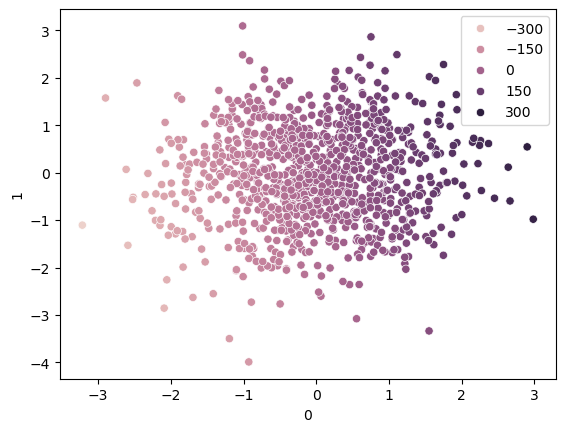

In [37]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1], hue=y)

In [22]:
from sklearn.model_selection import train_test_split as tts
X_train, X_test, y_train, y_test=tts(X, y, test_size=0.30, random_state=1)

In [23]:
X_train.shape, X_test.shape

((700, 2), (300, 2))

In [38]:
from sklearn.svm import SVR
model=SVR(kernel='linear')

In [39]:
model

SVR(kernel='linear')

In [40]:
model.fit(X_train, y_train)

SVR(kernel='linear')

In [41]:
model.coef_

array([[82.87495573, 30.80596913]])

In [43]:
len(model.support_vectors_)

684

In [45]:
y_pred=model.predict(X_test)
y_pred

array([-3.49095529e+01,  6.13664150e+01,  2.79924093e+01,  3.37066141e+01,
        6.74722645e+01, -1.86687041e+02, -7.03387505e+01,  8.43706145e+01,
        3.72474426e+01, -3.20129602e+01,  1.16135906e+02, -8.24446992e+01,
       -3.29149076e+01,  2.52319253e+01,  5.33632845e+01, -2.01159943e+01,
        1.35074840e+02, -3.90714669e+00,  8.14789653e+01, -1.14220344e+02,
       -9.40101064e+01,  6.98849885e+01,  3.83193412e+01, -1.76277175e+01,
        3.53380961e+01,  1.39550319e+02, -1.01340391e+02,  2.39586229e+02,
       -2.04559924e+01, -1.39720418e+01, -7.34160992e+01,  9.12885765e+01,
       -1.65524162e+01,  6.25199666e+01, -1.57952454e+02, -1.94294831e+01,
        5.16512674e+01,  8.82587674e+01,  8.25975386e+00, -3.17411349e+01,
       -6.50982378e+01, -2.20529040e+02,  1.01562752e+02,  9.50951532e+01,
       -1.29227933e+01, -1.13240162e+01, -7.67721167e+01, -3.71772654e+01,
       -1.40752642e+02, -1.13353142e+02,  9.21501510e+00,  4.38249618e+01,
        7.52658063e+01,  

In [46]:
# evaluation metrics
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.998681172745831

In [47]:
# hyper param tuning
from sklearn.model_selection import GridSearchCV
params={
    'C':[1,2,3,5,10,50,100],
    'gamma':[1, 0.1, 0.2, 0.01, 0.001],
    'kernel':['linear'],
    'epsilon':[0.01, 0.1, 0.2, 0.3]
}

In [48]:
reg=GridSearchCV(SVR(), param_grid=params, cv=5, scoring='r2')
reg

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 3, 5, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.01, 0.001],
                         'kernel': ['linear']},
             scoring='r2')

In [49]:
reg.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 3, 5, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.01, 0.001],
                         'kernel': ['linear']},
             scoring='r2')

In [50]:
reg.best_params_

{'C': 100, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'linear'}

In [51]:
reg.best_score_

np.float64(0.998981440687919)

In [53]:
final_model=reg.best_estimator_

In [54]:
y_pred=final_model.predict(X_test)

In [55]:
r2_score(y_test, y_pred)

0.9987485732386736